In [4]:
import numpy as np
import pandas as pd
import _backend_path  # noqa: F401
from app.fetch.yahoo import DataDownloader

dd = DataDownloader()
spy_px = dd.yahoo("SPY", "2016-01-01", "2025-12-31")[["Open","Adj_close"]]
spy_close = spy_px["Adj_close"]
spy_open = spy_px["Open"]

close_df = pd.read_csv("outputs/close_df.csv", index_col=0)
open_df = pd.read_csv("outputs/open_df.csv", index_col=0)
close_df.index = pd.to_datetime(close_df.index)
open_df.index = pd.to_datetime(open_df.index)
universe50 = pd.read_csv("outputs/universe50.csv")

# make close_df / open_df only have 50 stocks in universe50
tickers = list(universe50["ticker"])
close_df = close_df[tickers]
open_df = open_df[tickers]

Successfully got stock data for SPY


### Swing strategy (cross-sectional)

**Idea:** Rebalance every 5 trading days (swing cadence). Stay in names trading above an **EMA** (span set in code). Among those, equal-weight the top 10 by ~3-month momentum. Stock-level weights use a one-day shift (no look-ahead), and turnover is charged at `COST_PER_TURNOVER`.

**Risk stats:** Full-sample Sharpe, max DD, realized ann. vol. **Alpha / beta** vs SPY: OLS on daily returns, \(r_{strat} = \alpha + \beta \, r_{SPY} + \varepsilon\) (intercept annualized × 252); no risk-free adjustment unless you add a series.

**Baseline:** SPY buy-and-hold on the same dates.

Swing basket (50-stock universe)
  Total return (net):       716.93%
  CAGR (geom., net):        23.44%
  Ann. Sharpe (net):        1.17
  Realized ann. vol (net):  19.66%
  Max drawdown:             -31.33%
  Calmar (CAGR / |maxDD|):  0.75
  Mean ann. turnover:       25.81
  SPY total (same dates):   303.24%
  vs SPY (info ratio):      0.51


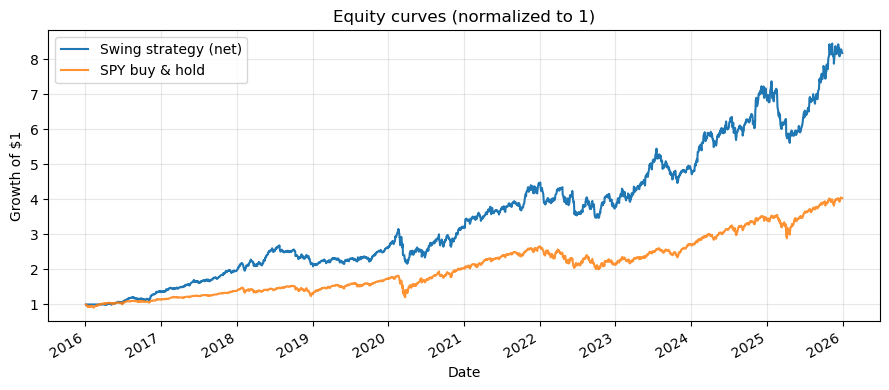

In [15]:
import matplotlib.pyplot as plt

# --- parameters (swing-style: weekly rebalance, multi-week holding signal) ---
REBAL_EVERY = 5          # trading days between portfolio updates
TOP_N = 10
EMA_SPAN = 50
MOM_DAYS = 63
COST_PER_TURNOVER = 0.001  # 10 bps per unit weight traded (tune to your broker)

px = close_df.sort_index().astype(float)
ret = px.pct_change()

mom = px / px.shift(MOM_DAYS) - 1.0
ema = px.ewm(span=EMA_SPAN, adjust=False).mean()
eligible = px > ema

weights = pd.DataFrame(np.nan, index=px.index, columns=px.columns)
start_i = max(MOM_DAYS, EMA_SPAN) + 1
idx = np.arange(start_i, len(px), REBAL_EVERY)

for i in idx:
    e = eligible.iloc[i]
    m = mom.iloc[i].copy()
    m = m.where(e, -np.inf)
    m = m.replace([np.inf, -np.inf], np.nan).fillna(-np.inf)
    top = m.nlargest(TOP_N)
    picked = top.index[np.isfinite(top.values)]
    row = pd.Series(0.0, index=px.columns)
    if len(picked) > 0:
        row.loc[picked] = 1.0 / len(picked)
    weights.iloc[i] = row

weights = weights.ffill().fillna(0.0)
pos = weights.shift(1).fillna(0.0)

gross = (pos * ret).sum(axis=1)
turnover = pos.diff().abs().sum(axis=1).fillna(0.0)
net = gross - turnover * COST_PER_TURNOVER

spy_ret = spy_close.sort_index().astype(float).pct_change().reindex(net.index).fillna(0.0)

def eval_strategy(
    r: pd.Series,
    bench: pd.Series,
    turnover_s: pd.Series,
    name: str,
):
    r = r.dropna()
    bench = bench.reindex(r.index).fillna(0.0)
    turnover_s = turnover_s.reindex(r.index).fillna(0.0)
    ann = 252
    eq = (1 + r).cumprod()
    sh = r.mean() / r.std() * np.sqrt(ann) if r.std() > 0 else np.nan
    ann_ret = (1 + r).prod() ** (ann / len(r)) - 1 if len(r) > 0 else np.nan
    rvol = r.std() * np.sqrt(ann)
    roll_max = eq.cummax()
    max_dd = (eq / roll_max - 1).min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 and not np.isnan(ann_ret) else np.nan
    tot = (1 + r).prod() - 1
    bh_tot = (1 + bench).prod() - 1
    excess = r - bench
    ir = excess.mean() / excess.std() * np.sqrt(ann) if excess.std() > 0 else np.nan
    print(f"{name}")
    print(f"  Total return (net):       {tot:.2%}")
    print(f"  CAGR (geom., net):        {ann_ret:.2%}")
    print(f"  Ann. Sharpe (net):        {sh:.2f}")
    print(f"  Realized ann. vol (net):  {rvol:.2%}")
    print(f"  Max drawdown:             {max_dd:.2%}")
    print(f"  Calmar (CAGR / |maxDD|):  {calmar:.2f}")
    print(f"  Mean ann. turnover:       {turnover_s.mean() * ann:.2f}")
    print(f"  SPY total (same dates):   {bh_tot:.2%}")
    print(f"  vs SPY (info ratio):      {ir:.2f}")
    return eq

eq_strat = eval_strategy(net, spy_ret, turnover, "Swing basket (50-stock universe)")

fig, ax = plt.subplots(figsize=(9, 4))
spy_eq = (1 + spy_ret).cumprod()
eq_strat.plot(ax=ax, label="Swing strategy (net)")
spy_eq.reindex(eq_strat.index).plot(ax=ax, label="SPY buy & hold", alpha=0.85)
ax.set_title("Equity curves (normalized to 1)")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Alpha / beta vs SPY (daily OLS on overlapping returns; no risk-free adjustment)
# r_strat = alpha + beta * r_SPY + eps  -> Jensen-style alpha: intercept annualized x 252

def ols_alpha_beta(y: pd.Series, x: pd.Series):
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(df) < 60:
        return (np.nan,) * 4
    Y = df["y"].to_numpy(dtype=float)
    Xb = df["x"].to_numpy(dtype=float)
    A = np.column_stack([np.ones(len(Xb)), Xb])
    coef, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
    alpha_d, beta = float(coef[0]), float(coef[1])
    resid = Y - A @ coef
    sse = float((resid ** 2).sum())
    sst = float(((Y - Y.mean()) ** 2).sum())
    r2 = 1.0 - sse / sst if sst > 0 else np.nan
    alpha_ann = alpha_d * 252.0
    return alpha_ann, beta, r2, len(df)


a_ann, b, r2, n = ols_alpha_beta(net, spy_ret)
print("vs SPY (same calendar, daily returns)")
print(f"  N overlapping days:  {n}")
print(f"  Beta:                {b:.3f}")
print(f"  Alpha (ann., interp): {a_ann:.2%}  # intercept x 252; not CAPM excess unless you add rf")
print(f"  R-squared:           {r2:.3f}")


vs SPY (same calendar, daily returns)
  N overlapping days:  2513
  Beta:                0.727
  Alpha (ann., interp): 6.96%  # intercept x 252; not CAPM excess unless you add rf
  R-squared:           0.474
